# Project 7: Supervised Learning and using Machine learning to predict and analyze

Author: Chau Palma

Repository: [Github] https://github.com/chaupalma81-commits/datafun-07-ml

Date: 02/25/26


In [38]:
# Import necessary libraries for data analysis, machine learning, and visualization

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split # type: ignore


## PART 1 Chart a straight line

Following the instructions found in 10.16

In [ ]:
# Calculating fahrenheit from celsius, c = 5 / 9 * (f - 32)

# Creating a lambda function to convert celsius to fahrenheit
c = lambda f: 5 / 9 * (f - 32)

temps = [(f, c(f)) for f in range(0, 101, 10)]

# Placing data in dataframe then plotting

temps_df = pd.DataFrame(temps, columns=["Fahrenheit", "Celsius"])

axes = temps_df.plot(x="Fahrenheit", y="Celsius", style=".-")

y_label = axes.set_ylabel("Celsius")





## Part 2 Prediction

Predict Avg High Temp in NYC in January

### Section 1: Data Acquisition

In [40]:
# Loading the average high temperatures into a dataframe

nyc_df = pd.read_csv("C:\\Repos\\datafun-07-ml\\Data\\ave_hi_nyc_jan_1895-2018.csv")

### Section 2: Data Inspection

In [41]:
# Displaying the head file
nyc_df.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


In [42]:
# Displaying the tail file
nyc_df.tail()

,Date,Value,Anomaly
119,201401,35.5,-1.9
120,201501,36.1,-1.3
121,201601,40.8,3.4
122,201701,42.8,5.4
123,201801,38.7,1.3


### Section 3 - Data Cleaning 

In [43]:
# Rename value column as temperature
nyc_df.columns = ["Date", "Temperature", "Anomaly"]

# Display the columns
nyc_df.head(3)

,Date,Temperature,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9


notes: the book mentions seaborn labels the tick marks on x-axis with date values, but wants to make it more readable if they do not contain 01 for january.

the next steps are to remove it from the Date.

In [44]:
# Checking column types

nyc_df.Date.dtype

dtype('int64')

In [45]:
# Calling the floordiv method to perform integer division on the Date column

nyc_df.Date = nyc_df.Date.floordiv(100)


# Display the new head

nyc_df.head(3)

,Date,Temperature,Anomaly
0,1895,34.2,-3.2
1,1896,34.7,-2.7
2,1897,35.5,-1.9


notes: the date column now looks cleaner without having 01 representing january as the data is only for january.

### Section 4 - Descriptive Statistics

In [49]:
# Display quick statistics with pd set option to 2
pd.set_option("display.precision", 2)

nyc_df.describe()


,Date,Temperature,Anomaly
count,124.00,124.00,124.00
mean,1956.50,37.60,0.20
std,35.94,4.54,4.54
min,1895.00,26.10,-11.30
25%,1925.75,34.58,-2.82
50%,1956.50,37.60,0.20
75%,1987.25,40.60,3.20
max,2018.00,47.60,10.20


### Section 5 - Build the Model 

In [51]:
# forecasting future high temperatures with linear regression
linear_regression = stats.linregress(x=nyc_df.Date, y=nyc_df.Temperature)

In [52]:
# Slope
linear_regression.slope

np.float64(0.014771361132966163)

In [53]:
# intercept
linear_regression.intercept

np.float64(8.694993233674289)

### Section 6: Predict

using the formula y = mx + b. Predict the temperature for 2024.  linear_regression.slope is m, 2024 is x, linear_regression.intercept is b.

In [54]:
# Predict the temperature in 2024
linear_regression.slope * 2024 + linear_regression.intercept

np.float64(38.5922281667978)

In [56]:
# Predict the temperature in 1890
linear_regression.slope * 1890 + linear_regression.intercept

np.float64(36.612865774980335)

### Section 7 - Visualizations

(10.0, 70.0)

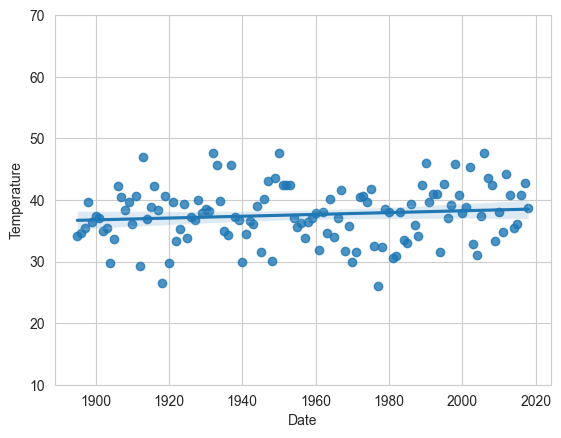

In [57]:
# Plotting the average high temperatures and a regression line with seaborn
sns.set_style("whitegrid")
axes = sns.regplot(x=nyc_df.Date, y=nyc_df.Temperature)

# Scale the y-axis ranges from 10 to 70 degrees
axes.set_ylim(10, 70)


notes: the reason why to set the scale to be higher and lower is to better represent the linear regression line, otherwise if left as is it would be difficult to interpret.

## Part 3 Prediction

Using scikit-learn estimator, and practice splitting data for training (to build a model) and testing (testing our model against known values)

### Section 1 - Build the Model

In [58]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(nyc_df.Date.values.reshape(-1, 1), nyc_df.Temperature.values, random_state=11)

In [59]:
# Confirm the 75-25 split of the data
X_train.shape

(93, 1)

In [60]:
# Confirm the 75-25 split of the data
X_test.shape

(31, 1)

In [61]:
# Train the model
linear_regression = LinearRegression()
linear_regression.fit(X=X_train, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
# Get the slope and intercept of the trained model
linear_regression.coef_, linear_regression.intercept_

(array([0.01939167]), np.float64(-0.30779820252656975))

notes: I understand now where sci-kit-learn would be the best approach to data as it provides more flexibility especially for larger data.

### Section 2 - Test the model

In [63]:
# Test the model using the data in X_test and check predicted and expected values for every 5th element.
predicted = linear_regression.predict(X_test)

expected = y_test

for p, e in zip(predicted[::5], expected[::5]):
    print(f"Predicted: {p:.2f}, Expected: {e:.2f}")

Predicted: 37.86, Expected: 31.70
Predicted: 38.69, Expected: 34.80
Predicted: 37.00, Expected: 39.40
Predicted: 37.25, Expected: 45.70
Predicted: 38.05, Expected: 32.30
Predicted: 37.64, Expected: 33.80
Predicted: 36.94, Expected: 39.70


### Section 3 - Predict

In [66]:
# Predicting future temperatures and estimating past temperatures with the trained model
predict = (lambda x: linear_regression.coef_ * x + linear_regression.intercept_)

In [69]:
# Predict 2024
predict(2024)

array([38.94094855])

In [70]:
# Predict 1890
predict(1890)

array([36.34246432])

## Section 4 - Visualization

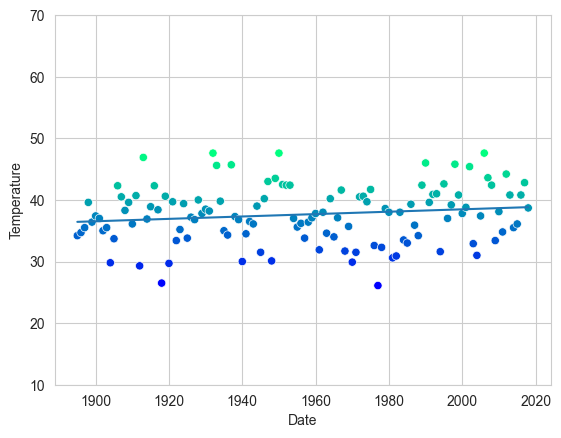

In [72]:
# Create a scatter plot of the dataset using seaborn and matplotlib
axes = sns.scatterplot(data=nyc_df, x="Date", y="Temperature", hue="Temperature", palette="winter", legend=False)

# Scale the y-axis range of values from 10 to 70
axes.set_ylim(10, 70)

# Create an array containing the minimum and maximum date values in nyc_df.Date
x = np.array([min(nyc_df.Date.values), max(nyc_df.Date.values)])

# Passing the array x to the predict lambda, which we'll use as the y-coordinates.
y = predict(x)

# Use matplotlib to plot a line based on the x and y arrays.
line = plt.plot(x, y)